# IVF Pregnancy Prediction Pipeline

## 변경사항 요약

### 제기된 의견 검증 결과

| 의견 | 판정 | 근거 및 조치 |
|---|---|---|
| Feature Selection 제거 또는 Permutation/Fold-avg Importance로 교체 | ✅ **맞음** | 전체 X fit → val 정보 포함 = leakage 성격. Fold-avg importance + permutation importance 방식으로 교체 |
| ExtraTrees 제거 (실험 결과 0.68로 저조) | ✅ **맞음** | EXT 0.68은 LGB/CAT 0.738과 격차가 너무 커 앙상블 다양성보다 노이즈가 큼. 제거 |
| Stacking 원본 feature 제거 | ✅ **맞음** | OOF 상관계수 0.95+ 이면 stacking 자체가 의미 없고, 원본 feature 추가는 leakage 성격 존재. 단순화 |
| OOF 상관계수 확인 후 stacking 여부 결정 | ✅ **맞음, 신규 추가** | corrcoef ≥ 0.98 → stacking 스킵, < 0.95 → stacking 효과 있음 |
| 전체 X로 feature importance 계산 → leakage 성격 | ✅ **맞음** | val fold 정보가 importance에 반영됨. **Fold-avg importance로 교체** |
| LGB 기준 importance bias | ✅ **맞음** | LGB importance ≠ 앙상블 기준 중요도. **LGB+CAT fold-avg 평균으로 교체** |
| Top-N 탐색 = CV 과적합 | ✅ **맞음** | N을 CV로 선택하면 selection 자체가 val 정보를 소비. **고정 threshold 방식으로 교체** |

### v7 핵심 구조 변경

```
[v6]  전체X fit LGB importance → Top-N CV 탐색 → feature 선택 → OOF
[v7]  5-fold LGB+CAT importance 평균 → importance 0 제거만 → OOF (leakage-free)
      + Permutation importance 교차검증으로 결과 검증
      + OOF 상관계수 체크 → stacking 여부 자동 결정
      + Stacking 메타 피처: OOF 2개만 (원본 feature 제거)
```

### 유지 사항
- 바이오 도메인 이상치 처리
- 결측치 leakage-free 처리
- LGB + CAT Optuna 튜닝
- Seed 앙상블 (3 seeds)
- Optuna 10 trial마다 진행 로그 출력
- 논문 기반 파생변수 17개 전체


## 설치

In [1]:
!pip install koreanize-matplotlib optuna catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.1 MB/s eta 0:00:00


## 라이브러리 임포트

In [2]:
import pandas as pd
import numpy as np
import time

import lightgbm as lgb
from catboost import CatBoostClassifier

import optuna
from optuna.samplers import TPESampler

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.rcParams['axes.unicode_minus'] = False
optuna.logging.set_verbosity(optuna.logging.WARNING)


## 데이터 로드

In [3]:
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")

TARGET = "임신 성공 여부"
ID_COL = "ID"

print(f"Train: {train.shape}, Test: {test.shape}")


Train: (256351, 69), Test: (90067, 68)


## 데이터 탐색 (describe / info / 결측치 / 분포)

전처리 전 원본 데이터를 탐색하여 이상치 기준 및 결측 패턴을 파악합니다.


In [4]:
print("="*60)
print("[Train] dtypes & non-null counts")
print("="*60)
train.info()


[Train] dtypes & non-null counts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256351 entries, 0 to 256350
Data columns (total 69 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     256351 non-null  object 
 1   시술 시기 코드               256351 non-null  object 
 2   시술 당시 나이               256351 non-null  object 
 3   임신 시도 또는 마지막 임신 경과 연수  9370 non-null    float64
 4   시술 유형                  256351 non-null  object 
 5   특정 시술 유형               256349 non-null  object 
 6   배란 자극 여부               256351 non-null  int64  
 7   배란 유도 유형               256351 non-null  object 
 8   단일 배아 이식 여부            250060 non-null  float64
 9   착상 전 유전 검사 사용 여부       2718 non-null    float64
 10  착상 전 유전 진단 사용 여부       250060 non-null  float64
 11  남성 주 불임 원인             256351 non-null  int64  
 12  남성 부 불임 원인             256351 non-null  int64  
 13  여성 주 불임 원인             256351 non-null  int64  
 14  여성 

In [5]:
print("[Train] 수치형 기술통계")
train.describe(include="number").T


[Train] 수치형 기술통계


,count,mean,std,min,25%,50%,75%,max
임신 시도 또는 마지막 임신 경과 연수,9370.0,9.270651,3.550313,0.0,7.0,9.0,11.0,20.0
배란 자극 여부,256351.0,0.771286,0.420005,0.0,1.0,1.0,1.0,1.0
단일 배아 이식 여부,250060.0,0.233476,0.423043,0.0,0.0,0.0,0.0,1.0
착상 전 유전 검사 사용 여부,2718.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
착상 전 유전 진단 사용 여부,250060.0,0.012781,0.112328,0.0,0.0,0.0,0.0,1.0
남성 주 불임 원인,256351.0,0.028516,0.166441,0.0,0.0,0.0,0.0,1.0
남성 부 불임 원인,256351.0,0.013115,0.113767,0.0,0.0,0.0,0.0,1.0
여성 주 불임 원인,256351.0,0.030724,0.172568,0.0,0.0,0.0,0.0,1.0
여성 부 불임 원인,256351.0,0.012432,0.110805,0.0,0.0,0.0,0.0,1.0
부부 주 불임 원인,256351.0,0.033068,0.178814,0.0,0.0,0.0,0.0,1.0


In [6]:
print("[Train] 범주형 기술통계")
train.describe(include="object").T


[Train] 범주형 기술통계


,count,unique,top,freq
ID,256351,256351,TRAIN_256350,1
시술 시기 코드,256351,7,TRDQAZ,38969
시술 당시 나이,256351,7,만18-34세,102476
시술 유형,256351,2,IVF,250060
특정 시술 유형,256349,24,ICSI,122368
배란 유도 유형,256351,4,기록되지 않은 시행,194432
배아 생성 주요 이유,250060,13,현재 시술용,233732
총 시술 횟수,256351,7,0회,97599
클리닉 내 총 시술 횟수,256351,7,0회,121675
IVF 시술 횟수,256351,7,0회,103934


In [7]:
print("[Test] 수치형 기술통계")
test.describe(include="number").T


[Test] 수치형 기술통계


,count,mean,std,min,25%,50%,75%,max
임신 시도 또는 마지막 임신 경과 연수,3297.0,9.340916,3.639339,0.0,7.0,9.0,12.0,20.0
배란 자극 여부,90067.0,0.774490,0.417920,0.0,1.0,1.0,1.0,1.0
단일 배아 이식 여부,87891.0,0.232788,0.422611,0.0,0.0,0.0,0.0,1.0
착상 전 유전 검사 사용 여부,933.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
착상 전 유전 진단 사용 여부,87891.0,0.012936,0.113001,0.0,0.0,0.0,0.0,1.0
남성 주 불임 원인,90067.0,0.028956,0.167684,0.0,0.0,0.0,0.0,1.0
남성 부 불임 원인,90067.0,0.012868,0.112706,0.0,0.0,0.0,0.0,1.0
여성 주 불임 원인,90067.0,0.030455,0.171837,0.0,0.0,0.0,0.0,1.0
여성 부 불임 원인,90067.0,0.012624,0.111645,0.0,0.0,0.0,0.0,1.0
부부 주 불임 원인,90067.0,0.033309,0.179442,0.0,0.0,0.0,0.0,1.0


In [8]:
def missing_summary(df, name):
    mis = df.isnull().sum()
    mis = mis[mis > 0].sort_values(ascending=False)
    if len(mis) == 0:
        print(f"[{name}] 결측치 없음")
        return
    pct = (mis / len(df) * 100).round(2)
    print(pd.DataFrame({"결측 수": mis, "결측률(%)": pct}).to_string())

missing_summary(train, "Train")
missing_summary(test,  "Test")


                         결측 수  결측률(%)
난자 해동 경과일              254915   99.44
PGS 시술 여부              254422   99.25
PGD 시술 여부              254172   99.15
착상 전 유전 검사 사용 여부       253633   98.94
임신 시도 또는 마지막 임신 경과 연수  246981   96.34
배아 해동 경과일              215982   84.25
난자 채취 경과일               57488   22.43
난자 혼합 경과일               53735   20.96
배아 이식 경과일               43566   16.99
저장된 배아 수                 6291    2.45
단일 배아 이식 여부              6291    2.45
배아 생성 주요 이유              6291    2.45
착상 전 유전 진단 사용 여부         6291    2.45
총 생성 배아 수                6291    2.45
미세주입된 난자 수               6291    2.45
기증 배아 사용 여부              6291    2.45
해동 난자 수                  6291    2.45
미세주입 후 저장된 배아 수          6291    2.45
해동된 배아 수                 6291    2.45
미세주입 배아 이식 수             6291    2.45
이식된 배아 수                 6291    2.45
미세주입에서 생성된 배아 수          6291    2.45
수집된 신선 난자 수              6291    2.45
파트너 정자와 혼합된 난자 수         6291    2.45
신선 배아 사용 여부              6291    2.45
동결 배아 사용 여부 

In [9]:
# 범주형 고유값 (결측 표현 방식 파악)
for col in train.select_dtypes(include="object").columns:
    print(f"\n[{col}]")
    print(train[col].value_counts(dropna=False).head(10).to_string())



[ID]
ID
TRAIN_256350    1
TRAIN_000000    1
TRAIN_000001    1
TRAIN_000002    1
TRAIN_000003    1
TRAIN_000004    1
TRAIN_000005    1
TRAIN_000006    1
TRAIN_000007    1
TRAIN_000008    1

[시술 시기 코드]
시술 시기 코드
TRDQAZ    38969
TRCMWS    38090
TRYBLT    36713
TRVNRY    36173
TRJXFG    36031
TRZKPL    35544
TRXQMD    34831

[시술 당시 나이]
시술 당시 나이
만18-34세    102476
만35-37세     57780
만38-39세     39247
만40-42세     37348
만43-44세     12253
만45-50세      6918
알 수 없음        329

[시술 유형]
시술 유형
IVF    250060
DI       6291

[특정 시술 유형]
특정 시술 유형
ICSI                  122368
IVF                    91755
Unknown                26939
IUI                     6100
ICSI:ICSI               2314
ICSI / BLASTOCYST       1609
IVF / BLASTOCYST        1248
IVF:IVF                 1146
ICSI:IVF                 873
ICSI / AH                769

[배란 유도 유형]
배란 유도 유형
기록되지 않은 시행      194432
알 수 없음           61917
세트로타이드 (억제제)         1
생식선 자극 호르몬           1

[배아 생성 주요 이유]
배아 생성 주요 이유
현재 시술용                 233732
배아 저장용 

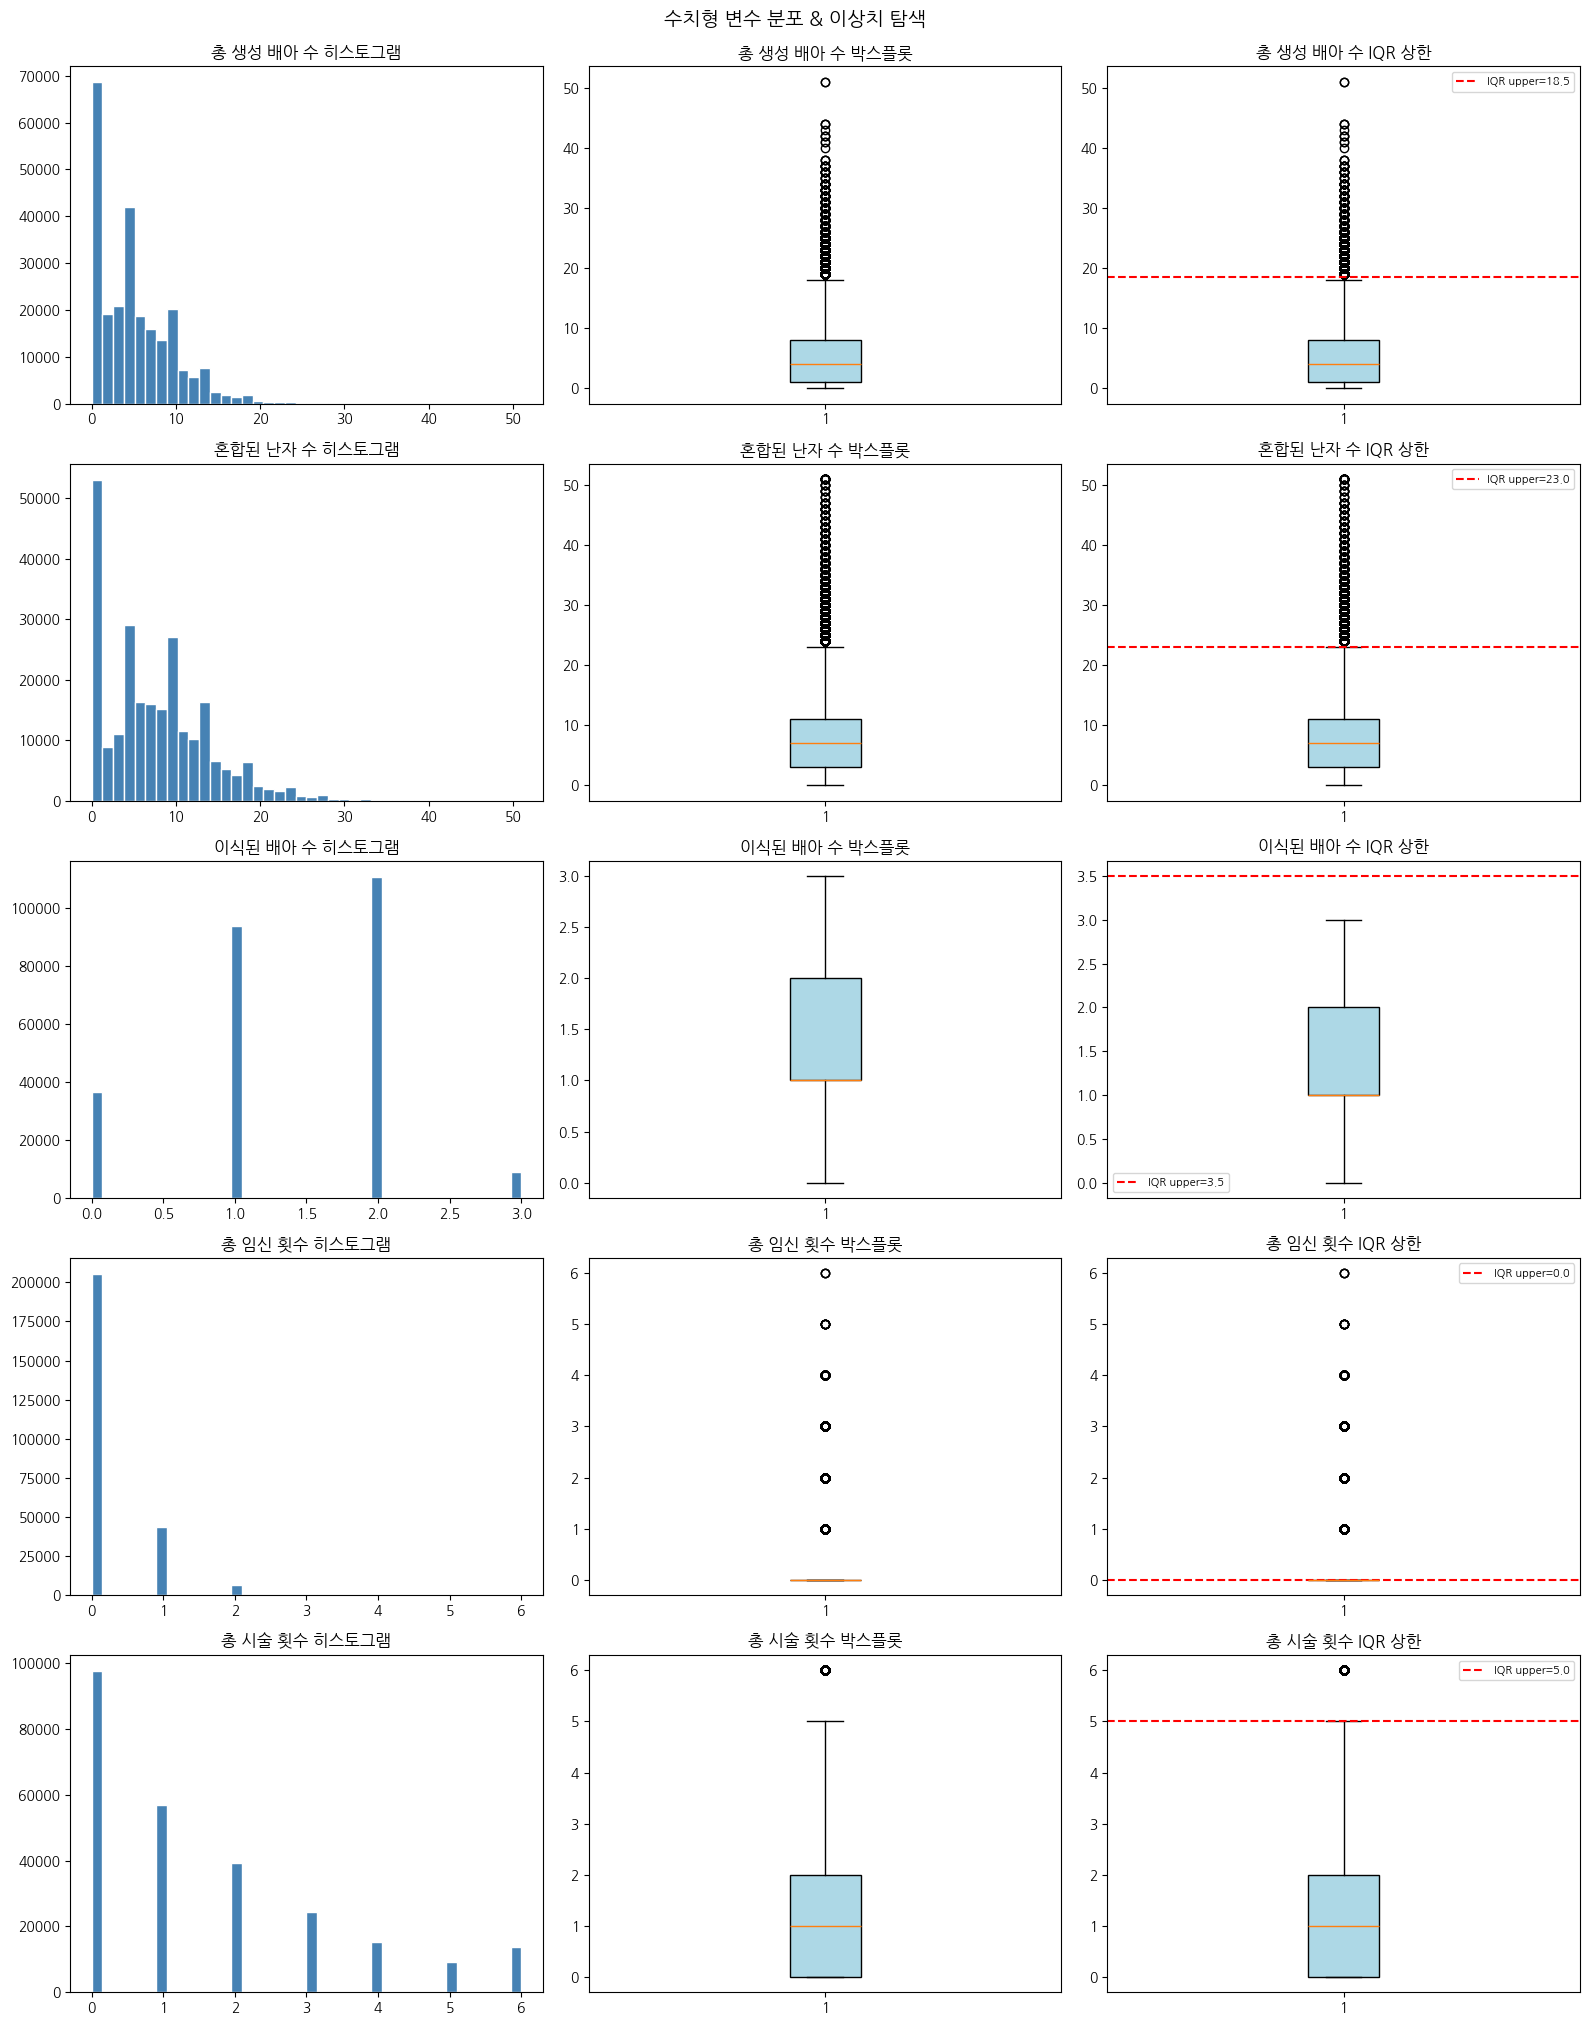

In [10]:
def convert_count_tmp(series):
    return series.astype(str).str.extract('(\\d+)')[0].astype(float)

inspect_cols = ["총 생성 배아 수", "혼합된 난자 수", "이식된 배아 수",
                "총 임신 횟수", "총 시술 횟수"]

fig, axes = plt.subplots(len(inspect_cols), 3,
                         figsize=(16, 4 * len(inspect_cols)))

for i, col in enumerate(inspect_cols):
    if col not in train.columns:
        continue
    s = (convert_count_tmp(train[col]) if "횟수" in col
         else pd.to_numeric(train[col], errors="coerce")).dropna()

    axes[i,0].hist(s, bins=40, color="steelblue", edgecolor="white")
    axes[i,0].set_title(f"{col} 히스토그램")

    axes[i,1].boxplot(s, patch_artist=True,
                      boxprops=dict(facecolor="lightblue"))
    axes[i,1].set_title(f"{col} 박스플롯")

    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr    = q3 - q1
    upper  = q3 + 1.5 * iqr
    axes[i,2].boxplot(s, patch_artist=True,
                      boxprops=dict(facecolor="lightblue"))
    axes[i,2].axhline(upper, color="red", linestyle="--",
                      label=f"IQR upper={upper:.1f}")
    axes[i,2].set_title(f"{col} IQR 상한")
    axes[i,2].legend(fontsize=8)

plt.tight_layout()
plt.suptitle("수치형 변수 분포 & 이상치 탐색", y=1.01, fontsize=14)
plt.show()


Target 분포:
임신 성공 여부
0    190123
1     66228
Name: count, dtype: int64
불균형 비율: 0.348


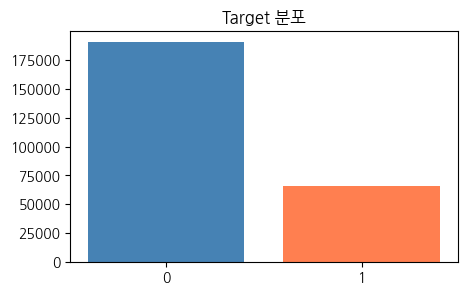

In [11]:
if TARGET in train.columns:
    vc = train[TARGET].value_counts()
    print("Target 분포:")
    print(vc)
    print(f"불균형 비율: {vc.min()/vc.max():.3f}")
    plt.figure(figsize=(5, 3))
    plt.bar(vc.index.astype(str), vc.values, color=["steelblue","coral"])
    plt.title("Target 분포")
    plt.show()


## 전처리 함수 정의

### 바이오 도메인 이상치 처리 기준

| 변수 | 생물학적 하한 | 임상 상한 | 근거 |
|---|---|---|---|
| `총 생성 배아 수` | 0 | 40 | Humaidan et al. (2010). *Hum Reprod Update* |
| `혼합된 난자 수` | 0 | 50 | Verberg et al. (2009). *Hum Reprod* |
| `이식된 배아 수` | 0 | 5 | ESHRE/ASRM 가이드라인 (Calhaz-Jorge et al., 2020) |
| `총 시술 횟수` | 1 | 20 | Olivius et al. (2004). *Fertil Steril* |
| `총 임신 횟수` | 0 | ≤시술횟수 | 논리적 제약 |
| `시술 당시 나이` | 18 | 50 | 임상 연령 범위 |

### 이상치 처리 순서
```
① 생물학적 불가능 값 → NaN (임상 상한/하한 위반)
② 논리적 모순 값    → NaN (임신횟수 > 시술횟수)
③ 결측치 대치       → train median 기준 (leakage-free)
④ 통계적 이상치     → IQR × 1.5 Winsorization (③ 이후 적용)
```


In [12]:
# =============================================================
# helpers
# =============================================================
def convert_count(series):
    return series.astype(str).str.extract('(\\d+)')[0].astype(float)

def drop_columns(df):
    return df.drop(columns=[c for c in [ID_COL] if c in df.columns],
                   errors="ignore")

def convert_str_to_numeric(df):
    age_map = {
        "만18-34세": 26, "만35-37세": 36, "만38-39세": 38.5,
        "만40-42세": 41, "만43-44세": 43.5, "만45-50세": 47,
        "알 수 없음": np.nan
    }
    if "시술 당시 나이" in df.columns:
        df["시술 당시 나이"] = df["시술 당시 나이"].map(age_map)
    for col in df.columns:
        if "횟수" in col:
            df[col] = convert_count(df[col])
    return df

# =============================================================
# Step 3. 생물학적 이상치 → NaN
# =============================================================
BIO_BOUNDS = {
    "총 생성 배아 수":  (0,  40),
    "혼합된 난자 수":  (0,  50),
    "이식된 배아 수":  (0,   5),
    "총 시술 횟수":    (1,  20),
    "총 임신 횟수":    (0,  None),
    "시술 당시 나이":  (18, 50),
}

def apply_bio_bounds(df):
    df = df.copy()
    for col, (lo, hi) in BIO_BOUNDS.items():
        if col not in df.columns:
            continue
        s = pd.to_numeric(df[col], errors="coerce")
        if lo is not None:
            s = s.where(s >= lo, other=np.nan)
        if hi is not None:
            s = s.where(s <= hi, other=np.nan)
        df[col] = s
    # 논리적 모순: 임신횟수 > 시술횟수
    if "총 임신 횟수" in df.columns and "총 시술 횟수" in df.columns:
        mask = (pd.to_numeric(df["총 임신 횟수"], errors="coerce") >
                pd.to_numeric(df["총 시술 횟수"], errors="coerce"))
        df.loc[mask, "총 임신 횟수"] = np.nan
    return df

# =============================================================
# Step 4. 결측치 대치 (leakage-free)
# =============================================================
def handle_missing(df, train_medians=None):
    df = df.copy()
    num_cols = [c for c in df.select_dtypes(include=["number"]).columns
                if c != TARGET]
    if train_medians is None:
        medians = {}
        for col in num_cols:
            medians[col] = df[col].median()
            df[col] = df[col].fillna(medians[col])
        for col in df.select_dtypes(include=["object"]).columns:
            df[col] = df[col].fillna("Unknown")
        return df, medians
    else:
        for col in num_cols:
            df[col] = df[col].fillna(train_medians.get(col, 0))
        for col in df.select_dtypes(include=["object"]).columns:
            df[col] = df[col].fillna("Unknown")
        return df

# =============================================================
# Step 5. IQR Winsorization (leakage-free: train bounds → test)
# =============================================================
IQR_CLIP_COLS = ["총 생성 배아 수", "혼합된 난자 수", "이식된 배아 수",
                 "총 시술 횟수", "총 임신 횟수"]

def compute_iqr_bounds(df):
    bounds = {}
    for col in IQR_CLIP_COLS:
        if col not in df.columns:
            continue
        s = pd.to_numeric(df[col], errors="coerce").dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr    = q3 - q1
        bounds[col] = (max(q1 - 1.5*iqr, 0), q3 + 1.5*iqr)
    return bounds

def apply_iqr_clip(df, iqr_bounds):
    df = df.copy()
    for col, (lo, hi) in iqr_bounds.items():
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").clip(lo, hi)
    return df

# =============================================================
# Step 6. Feature Engineering — 논문 기반 파생변수 17개
# =============================================================
ALL_PAPER_FEATURES = [
    "amh_proxy", "embryo_quality_score", "cumulative_success_proxy",
    "age_embryo_interaction", "transfer_burden", "oocyte_maturity_proxy",
    "high_responder", "prior_failure_penalty", "blastocyst_proxy",
    "freeze_thaw_proxy", "age_success_decline", "relative_efficiency",
    "treatment_intensity", "embryo_utilization_rate", "age_ivf_penalty",
    "poor_responder", "embryo_to_transfer_gap"
]

def create_features(df):
    base_cols = ["총 생성 배아 수", "혼합된 난자 수", "이식된 배아 수",
                 "총 임신 횟수", "총 시술 횟수"]
    for col in base_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    if "시술 유형" in df.columns:
        df["is_ivf"] = (df["시술 유형"] == 0).astype(int)
        df["is_di"]  = (df["시술 유형"] == 1).astype(int)

    for col in ["총 생성 배아 수", "혼합된 난자 수", "이식된 배아 수"]:
        if col in df.columns:
            df[f"{col}_log"] = np.log1p(df[col])

    df["배아_생성_효율"]  = df["총 생성 배아 수"] / (df["혼합된 난자 수"] + 1)
    df["이식_효율"]       = df["이식된 배아 수"]  / (df["총 생성 배아 수"] + 1)
    df["임신_성공률"]     = df["총 임신 횟수"]    / (df["총 시술 횟수"]  + 1)
    df["난자당_배아"]     = df["총 생성 배아 수"] / (df["혼합된 난자 수"] + 1)
    df["이식당_임신"]     = df["총 임신 횟수"]    / (df["이식된 배아 수"] + 1)
    df["실패_횟수"]       = df["총 시술 횟수"]    - df["총 임신 횟수"]
    df["실패율"]          = df["실패_횟수"]        / (df["총 시술 횟수"]  + 1)

    if "시술 당시 나이" in df.columns:
        df["배아_품질"] = df["총 생성 배아 수"] / (df["시술 당시 나이"] + 1)
        df["고령"]      = (df["시술 당시 나이"] >= 38).astype(int)

    df["경험지수"] = df["총 시술 횟수"] * df["임신_성공률"]
    df["ivf_효율"] = (df["배아_생성_효율"] * df["이식_효율"]
                      * df.get("is_ivf", pd.Series(0, index=df.index)))

    # ── 논문 기반 파생변수 ──────────────────────────────────────
    if "시술 당시 나이" in df.columns:
        df["amh_proxy"] = df["총 생성 배아 수"] / (df["시술 당시 나이"]**1.5 + 1)
        # [4] Templeton et al. (1996)
        df["age_embryo_interaction"] = df["배아_생성_효율"] / (df["시술 당시 나이"] + 1)
        # [11] SART (2020)
        df["age_success_decline"] = np.where(
            df["시술 당시 나이"] >= 38,
            np.exp(-(df["시술 당시 나이"] - 38) * 0.15), 1.0)
        # [15] van Loendersloot et al. (2010)
        if "is_ivf" in df.columns:
            df["age_ivf_penalty"] = (df["is_ivf"]
                * np.maximum(df["시술 당시 나이"] - 35, 0)**1.5)
        else:
            df["age_ivf_penalty"] = 0

    # [2] Steer et al. (1992)
    df["embryo_quality_score"]     = df["이식된 배아 수"] / (df["총 생성 배아 수"] + 1)
    # [3] Malizia et al. (2009)
    df["cumulative_success_proxy"]  = 1 - (1 - df["임신_성공률"])**(df["총 시술 횟수"] + 1)
    # [5] Gleicher et al. (2010)
    df["transfer_burden"]           = df["이식된 배아 수"] * np.log1p(df["총 시술 횟수"])
    # [6] Labarta et al. (2012)
    df["oocyte_maturity_proxy"]     = df["총 생성 배아 수"] / (df["혼합된 난자 수"]**0.5 + 1)
    # [7] Humaidan et al. (2010)
    df["high_responder"]            = (df["총 생성 배아 수"] >= 10).astype(int)
    # [8] Olivius et al. (2004)
    df["prior_failure_penalty"]     = df["실패_횟수"] / (df["총 시술 횟수"]**2 + 1)
    # [9] Gardner et al. (2000)
    df["blastocyst_proxy"]          = (df["이식된 배아 수"] / (df["총 생성 배아 수"] + 1))**2
    # [10] Roque et al. (2013)
    df["freeze_thaw_proxy"]         = np.log1p(
        np.maximum(df["총 생성 배아 수"] - df["이식된 배아 수"], 0))
    # [12] Verberg et al. (2009)
    df["relative_efficiency"]       = df["이식된 배아 수"] / (
        df["혼합된 난자 수"] + df["총 생성 배아 수"] + 1)
    # [13] Toftager et al. (2017)
    df["treatment_intensity"]       = (
        df["이식된 배아 수"] / (df["총 시술 횟수"] + 1)) * np.log1p(df["총 시술 횟수"])
    # [14] Drakopoulos et al. (2016)
    df["embryo_utilization_rate"]   = (
        df["총 임신 횟수"] * df["이식_효율"]) / (df["총 시술 횟수"] + 1)
    # [16] Ferraretti et al. (2011)
    df["poor_responder"]            = (df["총 생성 배아 수"] <= 3).astype(int)
    # [17] Cimadomo et al. (2018)
    df["embryo_to_transfer_gap"]    = (
        np.log1p(np.maximum(df["총 생성 배아 수"] - df["이식된 배아 수"], 0))
        * df["이식_효율"])

    return df

# =============================================================
# Step 7. Categorical encoding
# =============================================================
def encode_categorical(train_df, test_df):
    cat_cols = [c for c in train_df.select_dtypes(include=["object"]).columns
                if c != TARGET]
    for col in cat_cols:
        le = LabelEncoder()
        train_df[col] = le.fit_transform(train_df[col].astype(str))
        mapping = {k: v for v, k in enumerate(le.classes_)}
        test_df[col] = test_df[col].astype(str).map(mapping).fillna(-1).astype(int)
    return train_df, test_df

# =============================================================
# Full pipeline
# =============================================================
def preprocess(train, test):
    train = drop_columns(train);  test = drop_columns(test)
    train = convert_str_to_numeric(train); test = convert_str_to_numeric(test)

    for col in train.select_dtypes(include=["object"]).columns:
        train[col] = train[col].fillna("Unknown")
    for col in test.select_dtypes(include=["object"]).columns:
        test[col] = test[col].fillna("Unknown")

    train = apply_bio_bounds(train);  test = apply_bio_bounds(test)
    train, train_medians = handle_missing(train)
    test = handle_missing(test, train_medians=train_medians)

    iqr_bounds = compute_iqr_bounds(train)
    train = apply_iqr_clip(train, iqr_bounds)
    test  = apply_iqr_clip(test,  iqr_bounds)

    train = create_features(train); test = create_features(test)
    train, test = encode_categorical(train, test)
    return train, test, iqr_bounds


## 전처리 실행 + QC

In [13]:
train_df, test_df, iqr_bounds = preprocess(train, test)

X = train_df.drop(columns=[TARGET])
y = train_df[TARGET]

print(f"전처리 후 X shape: {X.shape}")
print(f"논문 기반 feature: {[c for c in X.columns if c in ALL_PAPER_FEATURES]}")
print(f"\nIQR 클리핑 범위:")
for col, (lo, hi) in iqr_bounds.items():
    print(f"  {col}: [{lo:.2f}, {hi:.2f}]")

# 결측치 0 검증
assert train_df.isnull().sum().sum() == 0, "Train 결측치 잔존"
assert test_df.isnull().sum().sum()  == 0, "Test 결측치 잔존"
print("\n결측치 처리 완료 ✓")


전처리 후 X shape: (256351, 100)
논문 기반 feature: ['amh_proxy', 'age_embryo_interaction', 'age_success_decline', 'age_ivf_penalty', 'embryo_quality_score', 'cumulative_success_proxy', 'transfer_burden', 'oocyte_maturity_proxy', 'high_responder', 'prior_failure_penalty', 'blastocyst_proxy', 'freeze_thaw_proxy', 'relative_efficiency', 'treatment_intensity', 'embryo_utilization_rate', 'poor_responder', 'embryo_to_transfer_gap']

IQR 클리핑 범위:
  총 생성 배아 수: [0.00, 18.50]
  혼합된 난자 수: [0.00, 23.00]
  이식된 배아 수: [0.00, 3.50]
  총 시술 횟수: [2.00, 2.00]
  총 임신 횟수: [0.00, 0.00]

결측치 처리 완료 ✓


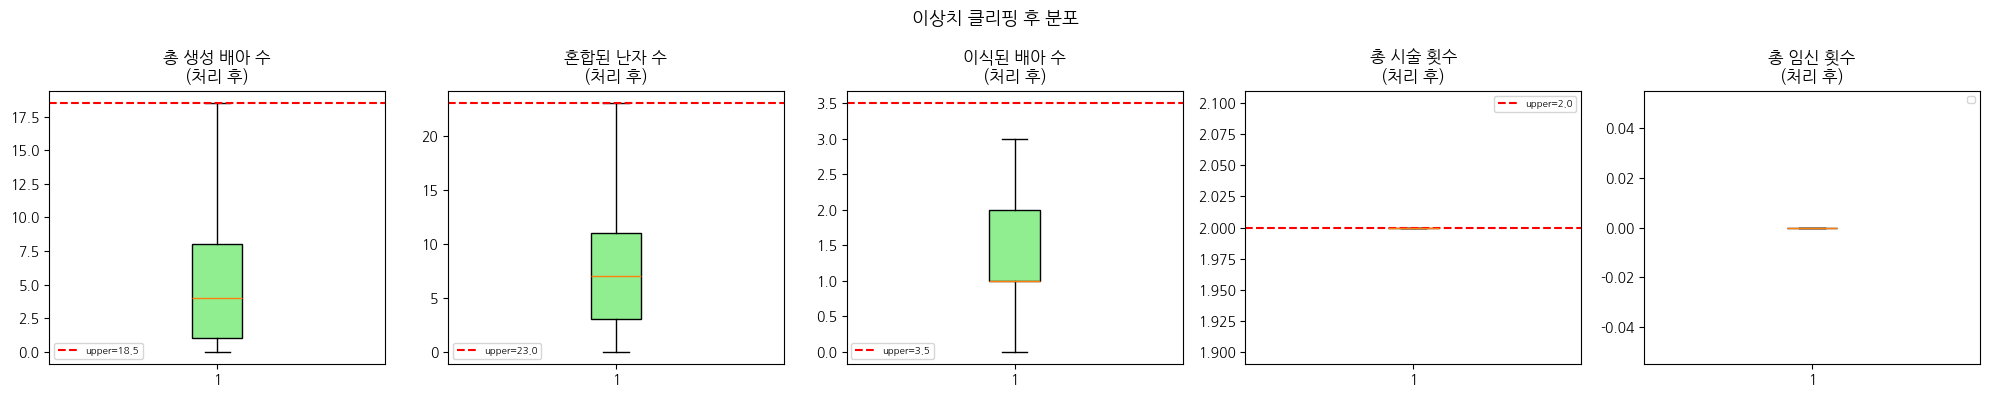

In [14]:
# 이상치 처리 후 분포 확인
compare_cols = [c for c in IQR_CLIP_COLS if c in train_df.columns]
fig, axes = plt.subplots(1, len(compare_cols), figsize=(4*len(compare_cols), 4))
if len(compare_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, compare_cols):
    ax.boxplot(train_df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor="lightgreen"))
    lo, hi = iqr_bounds.get(col, (None,None))
    if hi:
        ax.axhline(hi, color="red", linestyle="--", label=f"upper={hi:.1f}")
    ax.set_title(f"{col}\n(처리 후)"); ax.legend(fontsize=7)
plt.suptitle("이상치 클리핑 후 분포", fontsize=13)
plt.tight_layout(); plt.show()


## 빠른 모델 비교 (LGB / CAT)

> **ExtraTrees 제거**: 실험 결과 0.68로 LGB/CAT(0.738) 대비 격차 과도. 앙상블 다양성보다 노이즈가 커서 제거.  
> **XGBoost 제외**: 사전 실험 0.72대.


In [15]:
def quick_cv(model, name):
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []
    for tr_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        if name == "LGB":
            model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                      callbacks=[lgb.early_stopping(30, verbose=False)])
        else:
            model.fit(X_tr, y_tr, eval_set=(X_val, y_val), verbose=0)
        scores.append(roc_auc_score(y_val, model.predict_proba(X_val)[:,1]))
    return np.mean(scores)

print("LGB:", quick_cv(lgb.LGBMClassifier(n_estimators=500, verbosity=-1), "LGB"))
print("CAT:", quick_cv(CatBoostClassifier(iterations=500, verbose=0), "CAT"))


LGB: 0.73856904049079
CAT: 0.7385832501951602


## Optuna — LightGBM 튜닝

10 trial마다 진행 현황 로그를 출력합니다.


In [16]:
def make_progress_callback(study_name, total_trials):
    """10 trial마다 경과 시간 + 현재 best AUC 출력"""
    start = time.time()
    def callback(study, trial):
        n = trial.number + 1
        if n % 10 == 0 or n == total_trials:
            elapsed = time.time() - start
            print(f"[{study_name}] Trial {n:3d}/{total_trials} | "                  f"Best AUC: {study.best_value:.5f} | "                  f"Elapsed: {elapsed/60:.1f}min")
    return callback

def lgb_objective(trial):
    params = {
        "objective": "binary", "metric": "auc",
        "verbosity": -1, "n_jobs": -1,
        "n_estimators":      trial.suggest_int("n_estimators", 800, 2500),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.05, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 31, 300),
        "max_depth":         trial.suggest_int("max_depth", 4, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "min_split_gain":    trial.suggest_float("min_split_gain", 0.0, 1.0),
    }
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    aucs = []
    for tr_idx, val_idx in skf.split(X, y):
        m = lgb.LGBMClassifier(**params)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx],
              eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
              callbacks=[lgb.early_stopping(50, verbose=False)])
        aucs.append(roc_auc_score(y.iloc[val_idx],
                    m.predict_proba(X.iloc[val_idx])[:,1]))
    return np.mean(aucs)

LGB_TRIALS = 60
lgb_study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
lgb_study.optimize(lgb_objective, n_trials=LGB_TRIALS,
                   callbacks=[make_progress_callback("LGB", LGB_TRIALS)])

print(f"\nLGB Best AUC: {lgb_study.best_value:.5f}")
print(f"LGB Best Params: {lgb_study.best_params}")


[LGB] Trial  10/60 | Best AUC: 0.73904 | Elapsed: 15.0min
[LGB] Trial  20/60 | Best AUC: 0.73904 | Elapsed: 32.2min
[LGB] Trial  30/60 | Best AUC: 0.73915 | Elapsed: 51.4min
[LGB] Trial  40/60 | Best AUC: 0.73925 | Elapsed: 74.6min
[LGB] Trial  50/60 | Best AUC: 0.73934 | Elapsed: 94.3min
[LGB] Trial  60/60 | Best AUC: 0.73947 | Elapsed: 107.0min

LGB Best AUC: 0.73947
LGB Best Params: {'n_estimators': 809, 'learning_rate': 0.025961772343721757, 'num_leaves': 94, 'max_depth': 5, 'min_child_samples': 38, 'subsample': 0.684456263599153, 'colsample_bytree': 0.6089895439714106, 'reg_alpha': 9.113452767418526, 'reg_lambda': 2.846727253283904, 'min_split_gain': 0.004779581372885852}


## Optuna — CatBoost 튜닝

10 trial마다 진행 현황 로그를 출력합니다.


In [17]:
def cat_objective(trial):
    params = {
        "iterations":          trial.suggest_int("iterations", 500, 2000),
        "learning_rate":       trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "depth":               trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg":         trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_strength":     trial.suggest_float("random_strength", 0.0, 1.0),
        "border_count":        trial.suggest_int("border_count", 32, 255),
        "eval_metric": "AUC", "task_type": "GPU",
        "verbose": 0, "random_seed": 42,
    }
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    aucs = []
    for tr_idx, val_idx in skf.split(X, y):
        m = CatBoostClassifier(**params)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx],
              eval_set=(X.iloc[val_idx], y.iloc[val_idx]),
              early_stopping_rounds=50, verbose=0)
        aucs.append(roc_auc_score(y.iloc[val_idx],
                    m.predict_proba(X.iloc[val_idx])[:,1]))
    return np.mean(aucs)

CAT_TRIALS = 40
cat_study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
cat_study.optimize(cat_objective, n_trials=CAT_TRIALS,
                   callbacks=[make_progress_callback("CAT", CAT_TRIALS)])

print(f"\nCAT Best AUC: {cat_study.best_value:.5f}")
print(f"CAT Best Params: {cat_study.best_params}")


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric perio

[CAT] Trial  10/40 | Best AUC: 0.73919 | Elapsed: 3.5min


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric perio

[CAT] Trial  20/40 | Best AUC: 0.73929 | Elapsed: 8.0min


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric perio

[CAT] Trial  30/40 | Best AUC: 0.73929 | Elapsed: 11.9min


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric perio

[CAT] Trial  40/40 | Best AUC: 0.73929 | Elapsed: 17.5min

CAT Best AUC: 0.73929
CAT Best Params: {'iterations': 1689, 'learning_rate': 0.02882653704468059, 'depth': 5, 'l2_leaf_reg': 8.272594310024479, 'bagging_temperature': 0.630069067416033, 'random_strength': 0.6408830725507643, 'border_count': 125}


## Feature Importance — Fold-avg (Leakage-free) [v7 핵심 변경]

### 기존 방식의 문제점
```
전체 X로 LGB fit → feature_importances_
```
- **Leakage 성격**: val fold 정보가 importance에 포함됨
- **LGB bias**: LGB importance ≠ CAT/앙상블 기준 중요도

### v7 방식
```
5-fold CV 내부에서 LGB + CAT 각각 importance 계산 → fold별 평균
→ LGB/CAT 평균 importance 사용 (두 모델 편향 상쇄)
→ importance > 0 feature만 유지 (aggressive filtering 없음)
```


In [18]:
skf_imp = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lgb_imp_folds = []
cat_imp_folds = []

print("Feature Importance (Fold-avg) 계산 중...")

for fold, (tr_idx, val_idx) in enumerate(skf_imp.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    # LGB importance
    lgb_m = lgb.LGBMClassifier(**lgb_study.best_params)
    lgb_m.fit(X_tr, y_tr,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False)])
    lgb_imp_folds.append(lgb_m.feature_importances_)

    # CAT importance
    cat_m = CatBoostClassifier(**{**cat_study.best_params,
                                  "eval_metric":"AUC","task_type":"GPU","verbose":0})
    cat_m.fit(X_tr, y_tr,
              eval_set=(X_val, y_val),
              early_stopping_rounds=50, verbose=0)
    cat_imp_folds.append(cat_m.get_feature_importance())

    print(f"  Fold {fold+1} done")

# LGB + CAT fold 평균
lgb_imp_mean = np.mean(lgb_imp_folds, axis=0)
cat_imp_mean = np.mean(cat_imp_folds, axis=0)

# 두 모델 평균 (bias 상쇄)
combined_imp = (lgb_imp_mean / (lgb_imp_mean.sum() + 1e-10) +
                cat_imp_mean / (cat_imp_mean.sum() + 1e-10)) / 2

feat_imp = pd.DataFrame({
    "feature":      X.columns,
    "lgb_imp":      lgb_imp_mean,
    "cat_imp":      cat_imp_mean,
    "combined_imp": combined_imp,
}).sort_values("combined_imp", ascending=False).reset_index(drop=True)

print(f"\n전체 feature 수: {len(feat_imp)}")
print(f"importance > 0 feature 수: {(feat_imp['combined_imp'] > 0).sum()}")
print("\n논문 기반 feature 순위:")
print(feat_imp[feat_imp["feature"].isin(ALL_PAPER_FEATURES)]      [["feature","lgb_imp","cat_imp","combined_imp"]].to_string())


Feature Importance (Fold-avg) 계산 중...


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 1 done


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 2 done


...

  Fold 3 done


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 4 done


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 5 done

전체 feature 수: 100
importance > 0 feature 수: 80

논문 기반 feature 순위:
                     feature  lgb_imp    cat_imp  combined_imp
1        relative_efficiency    405.6  13.648591      0.082754
2       embryo_quality_score    127.8  15.184909      0.080497
6        treatment_intensity     13.6   7.380924      0.037391
7                  amh_proxy    376.2   3.650046      0.031710
12    age_embryo_interaction    667.8   0.424182      0.026013
14           transfer_burden     26.8   3.895009      0.020434
17          blastocyst_proxy     49.8   3.531698      0.019440
18    embryo_to_transfer_gap    341.6   1.320855      0.018826
19       age_success_decline    195.6   2.349905      0.018748
21     oocyte_maturity_proxy    434.0   0.305702      0.017056
49         freeze_thaw_proxy     79.8   0.024053      0.002975
68            poor_responder      0.0   0.039984      0.000200
72            high_responder      0.2   0.002518      0.000020
96  cumulative_success_proxy      0.0

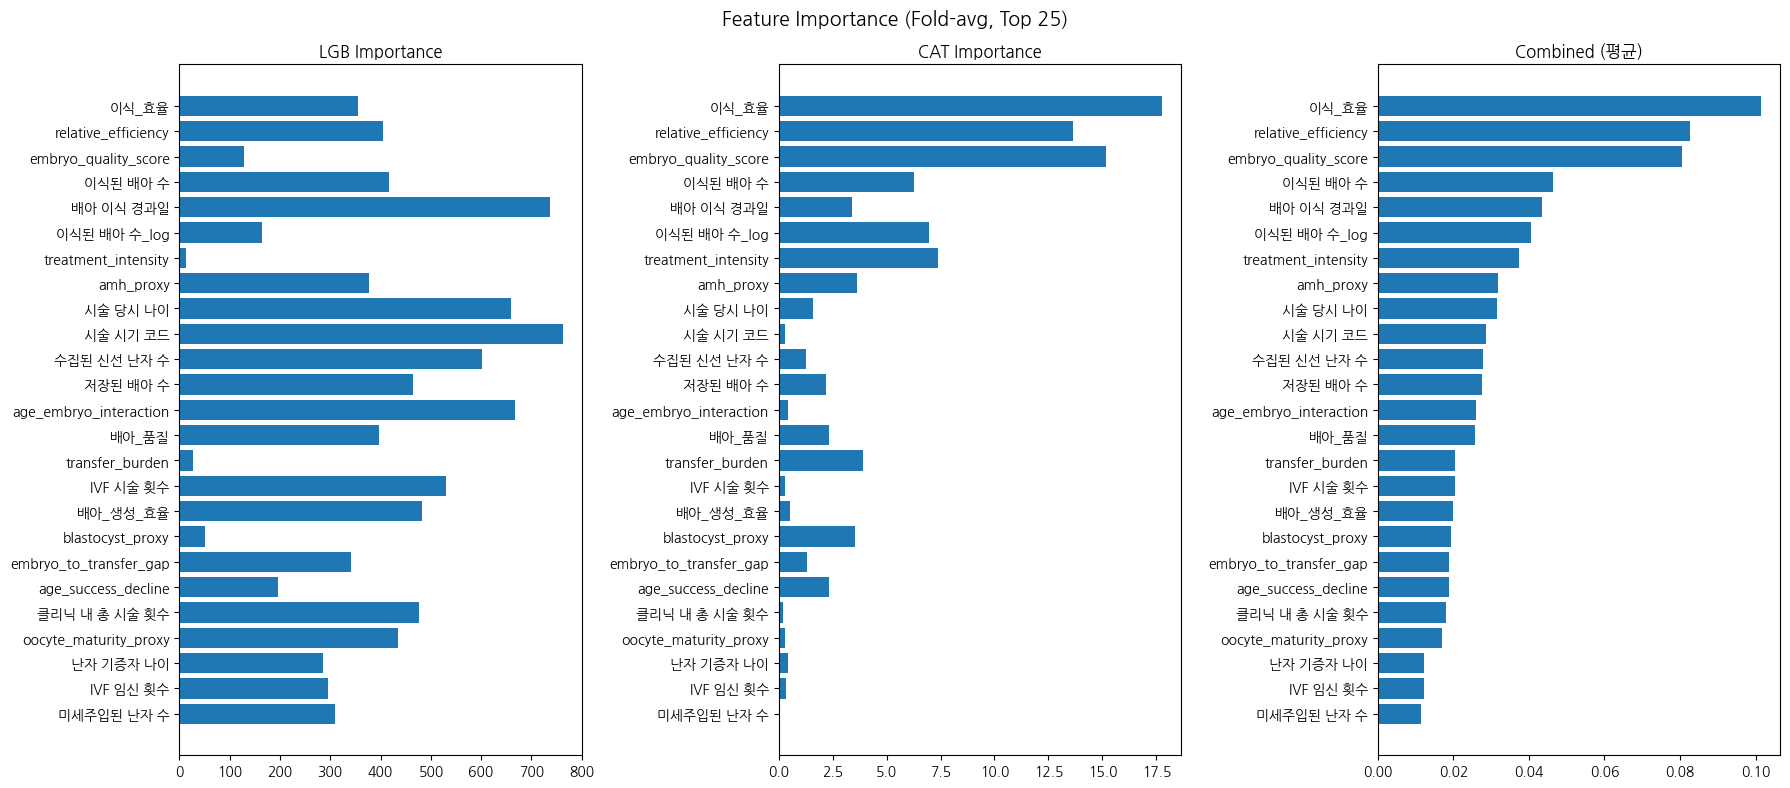

In [19]:
# Feature Importance 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for ax, imp_col, title in zip(
        axes,
        ["lgb_imp", "cat_imp", "combined_imp"],
        ["LGB Importance", "CAT Importance", "Combined (평균)"]):
    top = feat_imp.head(25)
    ax.barh(top["feature"], top[imp_col])
    ax.invert_yaxis()
    ax.set_title(title)

plt.suptitle("Feature Importance (Fold-avg, Top 25)", fontsize=14)
plt.tight_layout()
plt.show()


## Feature Selection — importance > 0 유지 (과적합 방지) [v7]

### 기존 Top-N CV 탐색의 문제
- N을 CV로 최적화 → val 정보로 feature 수를 선택 = **selection 과적합**
- LGB 기준으로 중요도 낮은 CAT-중요 feature가 제거될 수 있음

### v7 방식
- **LGB+CAT combined importance > 0** feature만 유지
- N 탐색 없음 → val 정보 미소비 → leakage-free
- 이 데이터셋 규모에서는 aggressive filtering보다 mild filtering이 일반적으로 더 안정적


In [20]:
# importance > 0 feature만 유지 (두 모델 combined 기준)
selected_features = feat_imp[feat_imp["combined_imp"] > 0]["feature"].tolist()

X_final    = X[selected_features]
test_final = test_df[selected_features]

print(f"선택된 feature 수: {len(selected_features)} / {len(X.columns)}")
print(f"포함된 논문 기반 feature: {[f for f in selected_features if f in ALL_PAPER_FEATURES]}")


선택된 feature 수: 80 / 100
포함된 논문 기반 feature: ['relative_efficiency', 'embryo_quality_score', 'treatment_intensity', 'amh_proxy', 'age_embryo_interaction', 'transfer_burden', 'blastocyst_proxy', 'embryo_to_transfer_gap', 'age_success_decline', 'oocyte_maturity_proxy', 'freeze_thaw_proxy', 'poor_responder', 'high_responder']


## Permutation Importance 검증 [v7 신규]

Fold-avg importance 결과를 **permutation importance**로 교차 검증합니다.  
상위 feature가 실제로 모델 성능에 기여하는지 확인합니다.  
(시간 절약을 위해 1-fold로 계산)


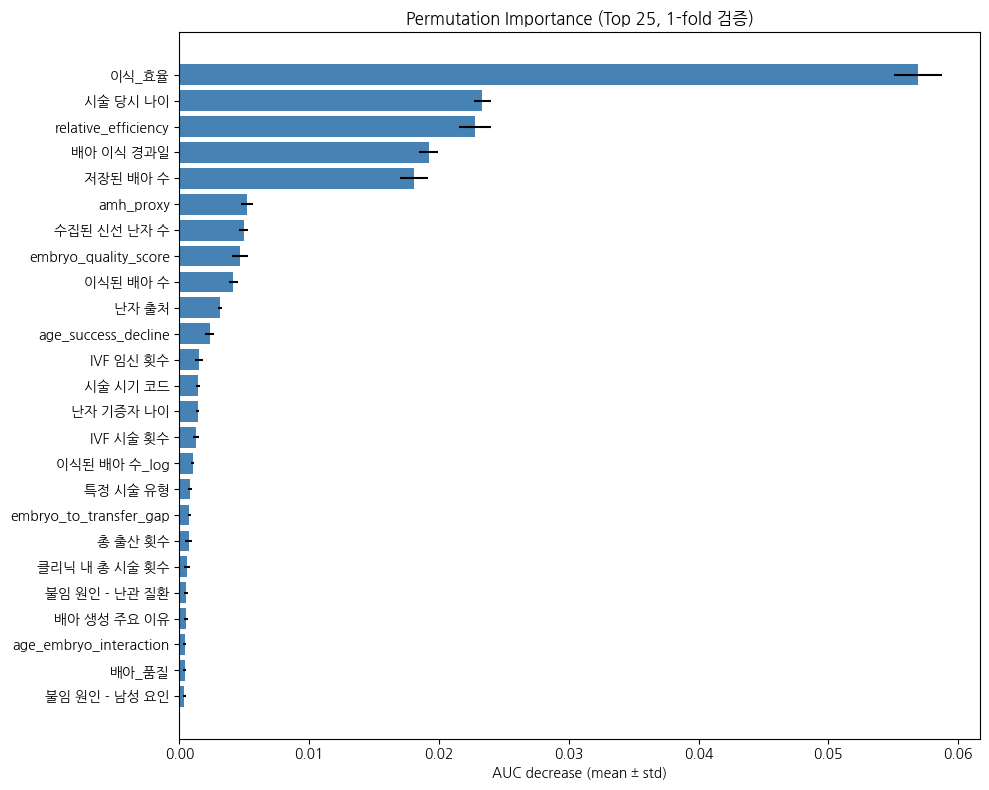


논문 기반 feature Permutation Importance:
                   feature  perm_mean  perm_std
2      relative_efficiency   0.022761  0.001259
5                amh_proxy   0.005189  0.000446
7     embryo_quality_score   0.004667  0.000638
10     age_success_decline   0.002317  0.000316
17  embryo_to_transfer_gap   0.000767  0.000132
22  age_embryo_interaction   0.000397  0.000114
31         transfer_burden   0.000103  0.000051
39     treatment_intensity   0.000049  0.000019
47   oocyte_maturity_proxy   0.000021  0.000084
53        blastocyst_proxy   0.000010  0.000015
62          poor_responder   0.000000  0.000000
68          high_responder   0.000000  0.000000
76       freeze_thaw_proxy  -0.000023  0.000009


In [21]:
# 1-fold permutation importance (검증용)
skf_perm = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tr_idx, val_idx = next(iter(skf_perm.split(X_final, y)))

perm_model = lgb.LGBMClassifier(**lgb_study.best_params)
perm_model.fit(X_final.iloc[tr_idx], y.iloc[tr_idx],
               eval_set=[(X_final.iloc[val_idx], y.iloc[val_idx])],
               callbacks=[lgb.early_stopping(50, verbose=False)])

perm_result = permutation_importance(
    perm_model, X_final.iloc[val_idx], y.iloc[val_idx],
    n_repeats=10, random_state=42,
    scoring="roc_auc", n_jobs=-1
)

perm_imp_df = pd.DataFrame({
    "feature":   X_final.columns,
    "perm_mean": perm_result.importances_mean,
    "perm_std":  perm_result.importances_std,
}).sort_values("perm_mean", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 8))
top_perm = perm_imp_df.head(25)
plt.barh(top_perm["feature"], top_perm["perm_mean"],
         xerr=top_perm["perm_std"], color="steelblue")
plt.gca().invert_yaxis()
plt.title("Permutation Importance (Top 25, 1-fold 검증)")
plt.xlabel("AUC decrease (mean ± std)")
plt.tight_layout()
plt.show()

print("\n논문 기반 feature Permutation Importance:")
print(perm_imp_df[perm_imp_df["feature"].isin(ALL_PAPER_FEATURES)].to_string())


## OOF 앙상블 (LGB + CAT) — Seed 앙상블

In [22]:
SEEDS    = [42, 123, 2024]
N_SPLITS = 5

oof_lgb_all  = []; oof_cat_all  = []
test_lgb_all = []; test_cat_all = []

for seed in SEEDS:
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)

    oof_lgb  = np.zeros(len(X_final))
    oof_cat  = np.zeros(len(X_final))
    test_lgb = np.zeros(len(test_final))
    test_cat = np.zeros(len(test_final))

    print(f"\n{'='*55}  Seed {seed}")

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_final, y)):
        X_tr, X_val = X_final.iloc[tr_idx], X_final.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx],       y.iloc[val_idx]

        lgb_m = lgb.LGBMClassifier(
            **{**lgb_study.best_params, "random_state": seed})
        lgb_m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(50, verbose=False)])

        cat_m = CatBoostClassifier(
            **{**cat_study.best_params,
               "random_seed": seed, "eval_metric": "AUC",
               "task_type": "GPU", "verbose": 0})
        cat_m.fit(X_tr, y_tr, eval_set=(X_val, y_val),
                  early_stopping_rounds=50, verbose=0)

        oof_lgb[val_idx] = lgb_m.predict_proba(
            X_val, num_iteration=lgb_m.best_iteration_)[:,1]
        oof_cat[val_idx] = cat_m.predict_proba(X_val)[:,1]

        test_lgb += lgb_m.predict_proba(
            test_final, num_iteration=lgb_m.best_iteration_)[:,1] / N_SPLITS
        test_cat += cat_m.predict_proba(test_final)[:,1] / N_SPLITS

        print(f"  Fold {fold+1} | "              f"LGB {roc_auc_score(y_val, oof_lgb[val_idx]):.5f} | "              f"CAT {roc_auc_score(y_val, oof_cat[val_idx]):.5f}")

    print(f"  OOF → LGB {roc_auc_score(y, oof_lgb):.5f} | "          f"CAT {roc_auc_score(y, oof_cat):.5f}")

    oof_lgb_all.append(oof_lgb); oof_cat_all.append(oof_cat)
    test_lgb_all.append(test_lgb); test_cat_all.append(test_cat)

oof_lgb_mean  = np.mean(oof_lgb_all, axis=0)
oof_cat_mean  = np.mean(oof_cat_all, axis=0)
test_lgb_mean = np.mean(test_lgb_all, axis=0)
test_cat_mean = np.mean(test_cat_all, axis=0)

print(f"\n[Seed 앙상블 평균]")
print(f"OOF LGB: {roc_auc_score(y, oof_lgb_mean):.5f}")
print(f"OOF CAT: {roc_auc_score(y, oof_cat_mean):.5f}")



=======================================================  Seed 42


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 1 | LGB 0.73780 | CAT 0.73810


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 2 | LGB 0.74232 | CAT 0.74274


...

  Fold 3 | LGB 0.74026 | CAT 0.74017


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 4 | LGB 0.73849 | CAT 0.73862


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 5 | LGB 0.73817 | CAT 0.73800
  OOF → LGB 0.73987 | CAT 0.73966

[Seed 앙상블 평균]
OOF LGB: 0.74006
OOF CAT: 0.73984


## OOF 상관계수 체크 → Stacking 여부 자동 결정 [v7 신규]

| 상관계수 | 해석 | 결정 |
|---|---|---|
| ≥ 0.98 | 두 모델이 거의 같은 예측 → stacking 무의미 | Weighted Average 사용 |
| 0.95 ~ 0.98 | 미미한 다양성 | Weighted Average 우선, stacking 선택적 |
| < 0.95 | 충분한 다양성 → stacking 효과 있음 | Stacking 시도 |


OOF 상관계수 (LGB vs CAT): 0.9966
→ 상관계수 ≥ 0.98: 두 모델 예측이 거의 동일 → Stacking 스킵, Weighted Average 사용


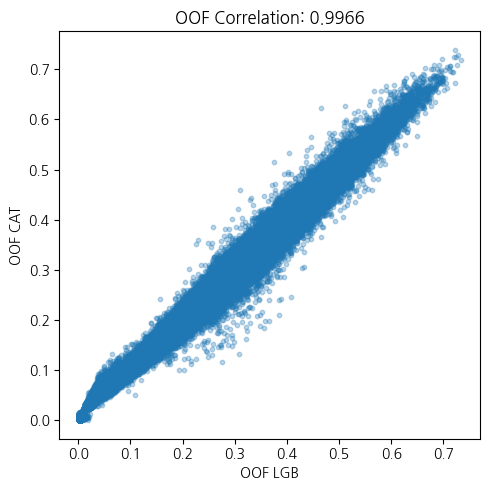

In [23]:
corr = np.corrcoef(oof_lgb_mean, oof_cat_mean)[0, 1]
print(f"OOF 상관계수 (LGB vs CAT): {corr:.4f}")

if corr >= 0.98:
    print("→ 상관계수 ≥ 0.98: 두 모델 예측이 거의 동일 → Stacking 스킵, Weighted Average 사용")
    SKIP_STACKING = True
elif corr >= 0.95:
    print("→ 상관계수 0.95~0.98: 미미한 다양성 → Stacking 시도하되 WA 우선")
    SKIP_STACKING = False
else:
    print("→ 상관계수 < 0.95: 충분한 다양성 → Stacking 효과 기대")
    SKIP_STACKING = False

plt.figure(figsize=(5, 5))
plt.scatter(oof_lgb_mean, oof_cat_mean, alpha=0.3, s=10)
plt.xlabel("OOF LGB"); plt.ylabel("OOF CAT")
plt.title(f"OOF Correlation: {corr:.4f}")
plt.tight_layout(); plt.show()


## Stacking — Ridge + LR 메타 앙상블 (OOF 2개만) [v7]

### v6 대비 변경
- **메타 피처**: OOF 2개 + top10 원본 feature → **OOF 2개만**
  - 원본 feature 추가는 leakage 성격 + 모델 복잡도만 증가
  - 상관계수 체크 후 stacking 스킵 가능
- **Scaler**: fold 내부 fit (leakage-free, v4와 동일)


In [24]:
if SKIP_STACKING:
    print("OOF 상관계수 ≥ 0.98 → Stacking 스킵")
    oof_stack_ensemble = None
    stack_preds = None
else:
    meta_train = np.column_stack([oof_lgb_mean, oof_cat_mean])
    meta_test  = np.column_stack([test_lgb_mean, test_cat_mean])

    skf_meta = StratifiedKFold(n_splits=5, shuffle=True, random_state=99)
    oof_stack_lr    = np.zeros(len(meta_train))
    oof_stack_ridge = np.zeros(len(meta_train))

    for tr_idx, val_idx in skf_meta.split(meta_train, y):
        sc = StandardScaler()
        X_meta_tr  = sc.fit_transform(meta_train[tr_idx])
        X_meta_val = sc.transform(meta_train[val_idx])

        lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
        lr.fit(X_meta_tr, y.iloc[tr_idx])
        oof_stack_lr[val_idx] = lr.predict_proba(X_meta_val)[:,1]

        ridge = RidgeClassifier(alpha=1.0)
        ridge.fit(X_meta_tr, y.iloc[tr_idx])
        df_val = ridge.decision_function(X_meta_val)
        oof_stack_ridge[val_idx] = 1 / (1 + np.exp(-df_val))

    oof_stack_ensemble = (oof_stack_lr + oof_stack_ridge) / 2

    print(f"Stacking LR    OOF AUC: {roc_auc_score(y, oof_stack_lr):.5f}")
    print(f"Stacking Ridge OOF AUC: {roc_auc_score(y, oof_stack_ridge):.5f}")
    print(f"Stacking 앙상블 OOF AUC: {roc_auc_score(y, oof_stack_ensemble):.5f}")

    sc_final = StandardScaler()
    meta_train_scaled = sc_final.fit_transform(meta_train)
    meta_test_scaled  = sc_final.transform(meta_test)

    lr_f    = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    ridge_f = RidgeClassifier(alpha=1.0)
    lr_f.fit(meta_train_scaled, y)
    ridge_f.fit(meta_train_scaled, y)

    stack_lr_preds    = lr_f.predict_proba(meta_test_scaled)[:,1]
    stack_ridge_df    = ridge_f.decision_function(meta_test_scaled)
    stack_ridge_preds = 1 / (1 + np.exp(-stack_ridge_df))
    stack_preds       = (stack_lr_preds + stack_ridge_preds) / 2


OOF 상관계수 ≥ 0.98 → Stacking 스킵


## 최종 예측 방법 선택 (Weighted Average vs Stacking)

In [25]:
best_score = 0
best_w = 0.5

for w in np.arange(0, 1.01, 0.05):
    score = roc_auc_score(y, w * oof_lgb_mean + (1-w) * oof_cat_mean)
    if score > best_score:
        best_score = score
        best_w = w

print(f"Best Weighted Average | w(LGB)={best_w:.2f} | AUC={best_score:.5f}")

if SKIP_STACKING or stack_preds is None:
    print("Stacking: 스킵됨")
    USE_STACKING = False
else:
    stack_score = roc_auc_score(y, oof_stack_ensemble)
    print(f"Stacking 앙상블 OOF AUC: {stack_score:.5f}")
    USE_STACKING = stack_score >= best_score
    print("\n→", "Stacking 채택" if USE_STACKING else "Weighted Average 채택")


Best Weighted Average | w(LGB)=0.65 | AUC=0.74017
Stacking: 스킵됨


## 제출 파일 생성

In [26]:
if USE_STACKING:
    final_preds = stack_preds
    print("최종 예측: Stacking (Ridge + LR 앙상블)")
else:
    final_preds = best_w * test_lgb_mean + (1-best_w) * test_cat_mean
    print(f"최종 예측: Weighted Average (LGB={best_w:.2f}, CAT={1-best_w:.2f})")

submission = pd.DataFrame({
    "ID":          test["ID"],
    "probability": final_preds
})
submission.to_csv("submission.csv", index=False)
print("\nsubmission.csv 저장 완료")
print(submission.head())
print("\nprobability 통계:")
print(submission["probability"].describe())


최종 예측: Weighted Average (LGB=0.65, CAT=0.35)

submission.csv 저장 완료
           ID  probability
0  TEST_00000     0.001775
1  TEST_00001     0.001067
2  TEST_00002     0.143734
3  TEST_00003     0.108666
4  TEST_00004     0.509314

probability 통계:
count    90067.000000
mean         0.258392
std          0.159116
min          0.000409
25%          0.145275
50%          0.269799
75%          0.378652
max          0.739053
Name: probability, dtype: float64
